In [169]:
import pandas as pd
import numpy as np

In [170]:
a = pd.read_csv('D:\\Python\\TekWorks\\Week_6\\amazon_laptop_price_dataset.csv')
df = pd.DataFrame(a)
df.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_USD
0,MSI,AMD Ryzen 3,4,512,macOS,AMD Radeon,4.2,1092.04
1,Lenovo,Intel i7,32,128,macOS,NVIDIA GTX 1650,3.1,1934.84
2,Asus,AMD Ryzen 7,8,256,Windows 10,Integrated,3.6,758.86
3,Dell,Intel i7,16,512,Windows 11,AMD Radeon,3.6,1430.88
4,MSI,AMD Ryzen 7,8,512,Windows 11,NVIDIA RTX 3050,3.8,1457.77


In [171]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   str    
 1   Processor         1000 non-null   str    
 2   RAM_GB            1000 non-null   int64  
 3   Storage_GB        1000 non-null   int64  
 4   Operating_System  1000 non-null   str    
 5   GPU               1000 non-null   str    
 6   Rating            1000 non-null   float64
 7   Price_USD         1000 non-null   float64
dtypes: float64(2), int64(2), str(4)
memory usage: 62.6 KB


In [172]:
df.describe()

,RAM_GB,Storage_GB,Rating,Price_USD
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,15.252000,460.032000,4.030300,1462.197300
std,10.693683,336.083691,0.580852,479.697515
min,4.000000,128.000000,3.000000,404.830000
25%,8.000000,128.000000,3.500000,1101.552500
50%,16.000000,256.000000,4.100000,1421.705000
75%,32.000000,512.000000,4.500000,1793.382500
max,32.000000,1024.000000,5.000000,2896.850000


In [173]:
df['Indian_Rupees'] = df['Price_USD']*92

In [174]:
df.drop('Price_USD',axis=1,inplace=True)

In [175]:
df.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Indian_Rupees
0,MSI,AMD Ryzen 3,4,512,macOS,AMD Radeon,4.2,100467.68
1,Lenovo,Intel i7,32,128,macOS,NVIDIA GTX 1650,3.1,178005.28
2,Asus,AMD Ryzen 7,8,256,Windows 10,Integrated,3.6,69815.12
3,Dell,Intel i7,16,512,Windows 11,AMD Radeon,3.6,131640.96
4,MSI,AMD Ryzen 7,8,512,Windows 11,NVIDIA RTX 3050,3.8,134114.84


<Axes: >

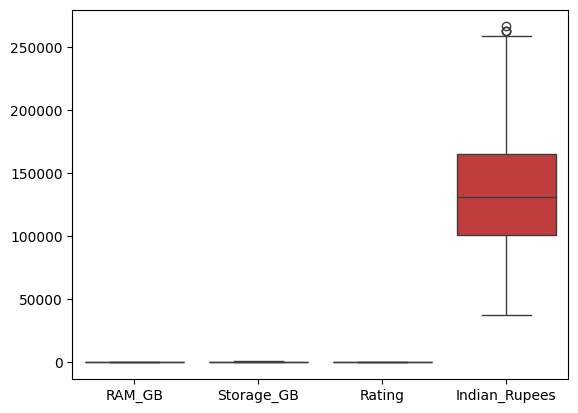

In [176]:
import seaborn as sns
sns.boxplot(data=df)

In [177]:
Q1=df['Indian_Rupees'].quantile(0.25)
Q3=df['Indian_Rupees'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['Indian_Rupees'] >= lower_bound) &(df['Indian_Rupees']<= upper_bound)]

In [178]:
df.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Indian_Rupees
0,MSI,AMD Ryzen 3,4,512,macOS,AMD Radeon,4.2,100467.68
1,Lenovo,Intel i7,32,128,macOS,NVIDIA GTX 1650,3.1,178005.28
2,Asus,AMD Ryzen 7,8,256,Windows 10,Integrated,3.6,69815.12
3,Dell,Intel i7,16,512,Windows 11,AMD Radeon,3.6,131640.96
4,MSI,AMD Ryzen 7,8,512,Windows 11,NVIDIA RTX 3050,3.8,134114.84


In [179]:
df.shape

(996, 8)

In [180]:
col = ['Brand','Processor','RAM_GB']
for c in col:
    print(c)
    print(df[c].value_counts())

Brand
Brand
Apple     154
MSI       149
Asus      144
Dell      144
Acer      142
HP        132
Lenovo    131
Name: count, dtype: int64
Processor
Processor
AMD Ryzen 7    182
Intel i5       176
AMD Ryzen 5    173
AMD Ryzen 3    158
Intel i7       157
Intel i3       150
Name: count, dtype: int64
RAM_GB
RAM_GB
8     263
16    254
32    252
4     227
Name: count, dtype: int64


In [181]:
mapping = {
    "Windows 10" : 0,
    "Windows 11" : 0,
    'macOS' : 1
}
df['Operating_System']=df['Operating_System'].map(mapping)
df.Operating_System.unique()

array([1, 0])

In [182]:
df.sample(10)

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Indian_Rupees
953,MSI,AMD Ryzen 3,8,128,0,NVIDIA GTX 1650,3.6,69664.24
186,Lenovo,Intel i7,16,256,0,NVIDIA GTX 1650,3.2,124474.16
468,Apple,Intel i7,32,128,1,Integrated,3.4,183084.60
682,Acer,Intel i5,16,512,0,AMD Radeon,4.0,118323.04
425,Asus,AMD Ryzen 7,4,512,0,Integrated,4.9,98250.48
717,Acer,Intel i5,32,256,0,Integrated,4.3,131468.00
119,HP,AMD Ryzen 7,32,512,0,AMD Radeon,3.5,165295.48
419,Acer,AMD Ryzen 7,8,256,0,AMD Radeon,4.6,94184.08
83,MSI,Intel i3,16,1024,0,AMD Radeon,3.1,150294.88
67,MSI,Intel i3,16,128,0,Integrated,4.1,66153.52


In [183]:
df.Processor.unique()

<StringArray>
['AMD Ryzen 3', 'Intel i7', 'AMD Ryzen 7', 'Intel i5', 'Intel i3',
 'AMD Ryzen 5']
Length: 6, dtype: str

In [184]:
df.GPU.unique()

<StringArray>
['AMD Radeon', 'NVIDIA GTX 1650', 'Integrated', 'NVIDIA RTX 3050']
Length: 4, dtype: str

In [185]:
df['GPU']=df['GPU'].replace({'AMD Radeon':1,
                   'NVIDIA GTX 1650' : 2,
                   'Integrated':3,
                   'NVIDIA RTX 3050':4},inplace=True)

C:\Users\vinee\AppData\Local\Temp\ipykernel_23544\3520060944.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['GPU']=df['GPU'].replace({'AMD Radeon':1,


In [186]:
df.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Indian_Rupees
0,MSI,AMD Ryzen 3,4,512,1,1,4.2,100467.68
1,Lenovo,Intel i7,32,128,1,2,3.1,178005.28
2,Asus,AMD Ryzen 7,8,256,0,3,3.6,69815.12
3,Dell,Intel i7,16,512,0,1,3.6,131640.96
4,MSI,AMD Ryzen 7,8,512,0,4,3.8,134114.84


In [187]:
df['Processor']=df['Processor'].replace({'AMD Ryzen 3':1,
                   'Intel i7' : 2,
                   'AMD Ryzen 7':3,
                   'Intel i5':4,
                   'Intel i3':5,
                   'AMD Ryzen 5':6},inplace=True)

C:\Users\vinee\AppData\Local\Temp\ipykernel_23544\2313317248.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Processor']=df['Processor'].replace({'AMD Ryzen 3':1,


In [188]:
df.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Indian_Rupees
0,MSI,1,4,512,1,1,4.2,100467.68
1,Lenovo,2,32,128,1,2,3.1,178005.28
2,Asus,3,8,256,0,3,3.6,69815.12
3,Dell,2,16,512,0,1,3.6,131640.96
4,MSI,3,8,512,0,4,3.8,134114.84


In [189]:
df.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Indian_Rupees
0,MSI,1,4,512,1,1,4.2,100467.68
1,Lenovo,2,32,128,1,2,3.1,178005.28
2,Asus,3,8,256,0,3,3.6,69815.12
3,Dell,2,16,512,0,1,3.6,131640.96
4,MSI,3,8,512,0,4,3.8,134114.84


In [190]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
df['Brand'] = lb.fit_transform(df['Brand'])

In [195]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [196]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=44)


In [197]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [198]:
y_pred = model.predict(x_test)


In [199]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
score

0.8048436319443968